<a href="https://colab.research.google.com/github/Rini43/Agricultural-Intelligence/blob/main/crop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

# Load all three datasets

In [82]:
filepath = "https://raw.githubusercontent.com/Rini43/Agricultural-Intelligence/main/data/raw/Crop_recommendation.csv"

crop_df = pd.read_csv(filepath)

display(crop_df.head(20))

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


In [83]:
print("Crop production:")

print(crop_df.shape)

Crop production:
(2200, 8)


In [84]:
print(crop_df.columns.tolist())

['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


In [85]:
filepath1 = "https://raw.githubusercontent.com/Rini43/Agricultural-Intelligence/main/data/raw/crop_production.csv"

production_df = pd.read_csv(filepath1)

display(production_df.head(20))

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.00
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.00
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.00
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.00
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.00
5,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Coconut,18168.0,65100000.00
6,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Dry ginger,36.0,100.00
7,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Sugarcane,1.0,2.00
8,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Sweet potato,5.0,15.00
9,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Tapioca,40.0,169.00


In [86]:
print("\n Production:")
print(production_df.shape)



 Production:
(246091, 7)


In [108]:
print("\nData types:")
print(production_df.dtypes)


Data types:
State_Name           object
District_Name        object
Crop_Year             int64
Season               object
Crop                 object
Area                float64
Production          float64
Yield_ton_per_ha    float64
dtype: object


In [110]:
print("\nMissing values:")
print(production_df.isnull().sum())


Missing values:
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production          0
Yield_ton_per_ha    0
dtype: int64


In [111]:
print("\nDuplicate rows:")
print(production_df.duplicated().sum())


Duplicate rows:
0


In [113]:
# Also check the unique values in the categorical columns:

print("Seasons:")
print(production_df['Season'].unique())

Seasons:
['Kharif     ' 'Whole Year ' 'Autumn     ' 'Rabi       ' 'Summer     '
 'Winter     ']


In [114]:
print("\nNumber of crops:", production_df['Crop'].nunique())
print("\nSample crops:")
print(production_df['Crop'].unique()[:20])


Number of crops: 124

Sample crops:
['Arecanut' 'Other Kharif pulses' 'Rice' 'Banana' 'Cashewnut' 'Coconut '
 'Dry ginger' 'Sugarcane' 'Sweet potato' 'Tapioca' 'Black pepper'
 'Dry chillies' 'other oilseeds' 'Turmeric' 'Maize' 'Moong(Green Gram)'
 'Urad' 'Arhar/Tur' 'Groundnut' 'Sunflower']


In [87]:
print(production_df.columns.tolist())

['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']


In [88]:
filepath2 = "https://raw.githubusercontent.com/Rini43/Agricultural-Intelligence/main/data/raw/weather.csv"

weather_df = pd.read_csv(filepath2)

display(weather_df.head(20))

,time,temperature_2m (Â°C),rain (mm),relative_humidity_2m (%),precipitation (mm),apparent_temperature (Â°C),soil_temperature_0_to_7cm (Â°C),soil_temperature_7_to_28cm (Â°C),soil_temperature_100_to_255cm (Â°C),soil_temperature_28_to_100cm (Â°C),soil_moisture_0_to_7cm (mÂ³/mÂ³),soil_moisture_7_to_28cm (mÂ³/mÂ³),soil_moisture_28_to_100cm (mÂ³/mÂ³),soil_moisture_100_to_255cm (mÂ³/mÂ³),vapour_pressure_deficit (kPa)
0,01-01-97,12.7,0.0,54,0.0,9.9,15.1,19.4,23.2,20.7,0.253,0.283,0.336,0.453,0.69
1,1/1/97 1:00,12.4,0.0,54,0.0,9.5,14.7,19.2,23.2,20.7,0.253,0.283,0.336,0.453,0.66
2,1/1/97 2:00,12.1,0.0,55,0.0,9.2,14.4,19.0,23.2,20.7,0.253,0.283,0.336,0.453,0.64
3,1/1/97 3:00,11.8,0.0,56,0.0,8.7,14.1,18.8,23.2,20.7,0.253,0.283,0.336,0.453,0.62
4,1/1/97 4:00,11.6,0.0,56,0.0,8.5,13.8,18.6,23.2,20.7,0.253,0.283,0.336,0.453,0.6
5,1/1/97 5:00,11.4,0.0,57,0.0,8.3,13.5,18.4,23.2,20.7,0.253,0.283,0.336,0.453,0.58
6,1/1/97 6:00,11.1,0.0,59,0.0,8.1,13.3,18.2,23.2,20.7,0.253,0.283,0.336,0.453,0.55
7,1/1/97 7:00,11.2,0.0,60,0.0,8.2,13.2,18.0,23.2,20.6,0.253,0.283,0.336,0.453,0.53
8,1/1/97 8:00,14.1,0.0,54,0.0,11.4,14.6,17.9,23.2,20.6,0.253,0.283,0.336,0.453,0.74
9,1/1/97 9:00,17.7,0.0,43,0.0,15.0,17.4,17.9,23.2,20.6,0.253,0.283,0.336,0.453,1.15


In [89]:
print("\nWeather:")
print(weather_df.shape)



Weather:
(271777, 15)


In [ ]:
print("\nData types:")
print(weather_df.dtypes)

In [ ]:
print("\nMissing values:")
print(weather_df.isnull().sum())

In [ ]:
print("\nDuplicate rows:", weather_df.duplicated().sum())

In [90]:
print(weather_df.columns.tolist())

['time', 'temperature_2m (Â°C)', 'rain (mm)', 'relative_humidity_2m (%)', 'precipitation (mm)', 'apparent_temperature (Â°C)', 'soil_temperature_0_to_7cm (Â°C)', 'soil_temperature_7_to_28cm (Â°C)', 'soil_temperature_100_to_255cm (Â°C)', 'soil_temperature_28_to_100cm (Â°C)', 'soil_moisture_0_to_7cm (mÂ³/mÂ³)', 'soil_moisture_7_to_28cm (mÂ³/mÂ³)', 'soil_moisture_28_to_100cm (mÂ³/mÂ³)', 'soil_moisture_100_to_255cm (mÂ³/mÂ³)', 'vapour_pressure_deficit (kPa)']


# Understand the crop-production dataset

In [91]:
# Dataset information
production_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


In [92]:
# Descriptive statistics
production_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
State_Name,246091,33,Uttar Pradesh,33306,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District_Name,246091,646,BIJAPUR,945,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop_Year,246091.0,NaN,NaN,NaN,2005.643018,4.952164,1997.0,2002.0,2006.0,2010.0,2015.0
Season,246091,6,Kharif,95951,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,246091,124,Rice,15104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,246091.0,NaN,NaN,NaN,12002.820864,50523.404019,0.04,80.0,582.0,4392.0,8580100.0
Production,242361.0,NaN,NaN,NaN,582503.442251,17065813.17241,0.0,88.0,729.0,7023.0,1250800000.0


In [93]:
# Check missing values
production_df.isnull().sum().sort_values(ascending=False)

,0
Production,3730
District_Name,0
State_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0


In [94]:
# Check duplicates
production_df.duplicated().sum()

np.int64(0)

In [95]:
# Check categorical values
for col in production_df.select_dtypes(include="object").columns:
    print("\n", col)
    print(production_df[col].nunique())
    print(production_df[col].unique()[:20])


 State_Name
33
['Andaman and Nicobar Islands' 'Andhra Pradesh' 'Arunachal Pradesh'
 'Assam' 'Bihar' 'Chandigarh' 'Chhattisgarh' 'Dadra and Nagar Haveli'
 'Goa' 'Gujarat' 'Haryana' 'Himachal Pradesh' 'Jammu and Kashmir '
 'Jharkhand' 'Karnataka' 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Manipur'
 'Meghalaya']

 District_Name
646
['NICOBARS' 'NORTH AND MIDDLE ANDAMAN' 'SOUTH ANDAMANS' 'ANANTAPUR'
 'CHITTOOR' 'EAST GODAVARI' 'GUNTUR' 'KADAPA' 'KRISHNA' 'KURNOOL'
 'PRAKASAM' 'SPSR NELLORE' 'SRIKAKULAM' 'VISAKHAPATANAM' 'VIZIANAGARAM'
 'WEST GODAVARI' 'ANJAW' 'CHANGLANG' 'DIBANG VALLEY' 'EAST KAMENG']

 Season
6
['Kharif     ' 'Whole Year ' 'Autumn     ' 'Rabi       ' 'Summer     '
 'Winter     ']

 Crop
124
['Arecanut' 'Other Kharif pulses' 'Rice' 'Banana' 'Cashewnut' 'Coconut '
 'Dry ginger' 'Sugarcane' 'Sweet potato' 'Tapioca' 'Black pepper'
 'Dry chillies' 'other oilseeds' 'Turmeric' 'Maize' 'Moong(Green Gram)'
 'Urad' 'Arhar/Tur' 'Groundnut' 'Sunflower']


# Calculate yield

In [96]:
production_df.columns

Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production'],
      dtype='object')

In [97]:
production_df["Yield_ton_per_ha"] = (
    production_df["Production"] / production_df["Area"]
)

In [115]:
display(production_df[["Crop", "Area", "Production", "Yield_ton_per_ha"]].head(20))

,Crop,Area,Production,Yield_ton_per_ha
0,Arecanut,1254.0,2000.00,1.594896
1,Other Kharif pulses,2.0,1.00,0.500000
2,Rice,102.0,321.00,3.147059
3,Banana,176.0,641.00,3.642045
4,Cashewnut,720.0,165.00,0.229167
5,Coconut,18168.0,65100000.00,3583.223250
6,Dry ginger,36.0,100.00,2.777778
7,Sugarcane,1.0,2.00,2.000000
8,Sweet potato,5.0,15.00,3.000000
9,Tapioca,40.0,169.00,4.225000


In [116]:
print("Zero area values:", (production_df["Area"] == 0).sum())

Zero area values: 0


# Remove impossible yield records

In [98]:

# Check invalid Area values
production_df[production_df["Area"] <= 0]

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield_ton_per_ha


In [99]:
# Check invalid Production values
production_df[production_df["Production"] < 0]

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield_ton_per_ha


In [100]:
# Remove invalid records
production_df = production_df[production_df["Area"] > 0]
production_df = production_df[production_df["Production"] >= 0]

In [101]:
# Check yield after cleaning
production_df["Yield_ton_per_ha"].describe()

,Yield_ton_per_ha
count,242361.000000
mean,41.649059
std,817.572839
min,0.000000
25%,0.513514
50%,1.000000
75%,2.355450
max,88000.000000


# Look for outliers

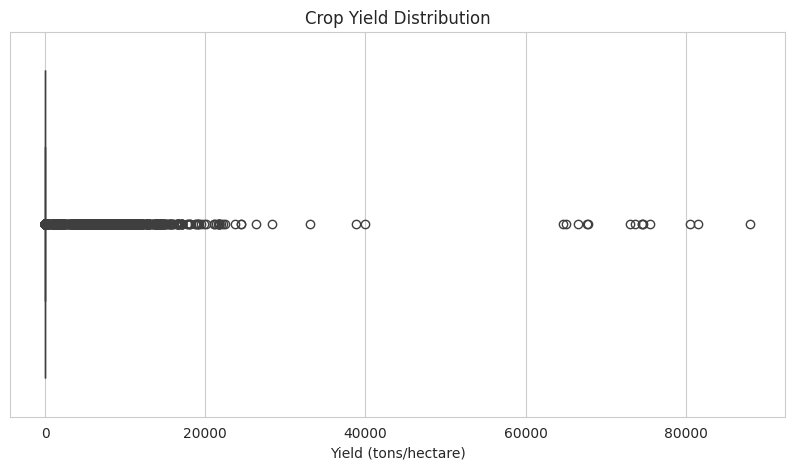

In [102]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    x=production_df["Yield_ton_per_ha"]
)

plt.title("Crop Yield Distribution")
plt.xlabel("Yield (tons/hectare)")
plt.show()

In [103]:
production_df["Yield_ton_per_ha"].quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

,Yield_ton_per_ha
0.01,0.000000
0.05,0.185049
0.25,0.513514
0.50,1.000000
0.75,2.355450
0.95,22.448276
0.99,82.663712


# Analyze which crops produce the most

In [104]:
production_summary = (
    production_df
    .groupby("Crop")
    .agg(
        total_production=("Production", "sum"),
        total_area=("Area", "sum"),
        avg_yield=("Yield_ton_per_ha", "mean")
    )
    .sort_values("total_production", ascending=False)
)

production_summary.head(15)

,total_production,total_area,avg_yield
Crop,,,
Coconut,1.299816e+11,2.833667e+07,4040.403568
Sugarcane,5.535682e+09,7.665622e+07,195.003397
Rice,1.605470e+09,7.463186e+08,1.995014
Wheat,1.332826e+09,4.707132e+08,2.092279
Potato,4.248263e+08,2.223278e+07,12.867025
Cotton(lint),2.970000e+08,1.565579e+08,2.063290
Maize,2.733418e+08,1.214845e+08,2.632770
Jute,1.815582e+08,1.472654e+07,9.456483
Banana,1.461327e+08,5.244768e+06,27.064755


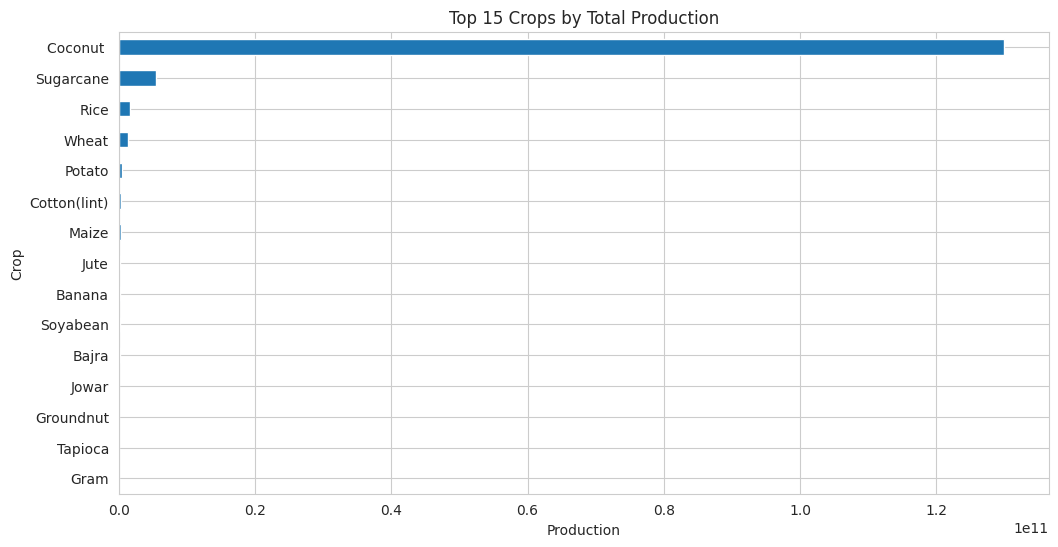

In [105]:
plt.figure(figsize=(12, 6))

production_summary.head(15)["total_production"].sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Crops by Total Production")
plt.xlabel("Production")
plt.ylabel("Crop")

plt.show()

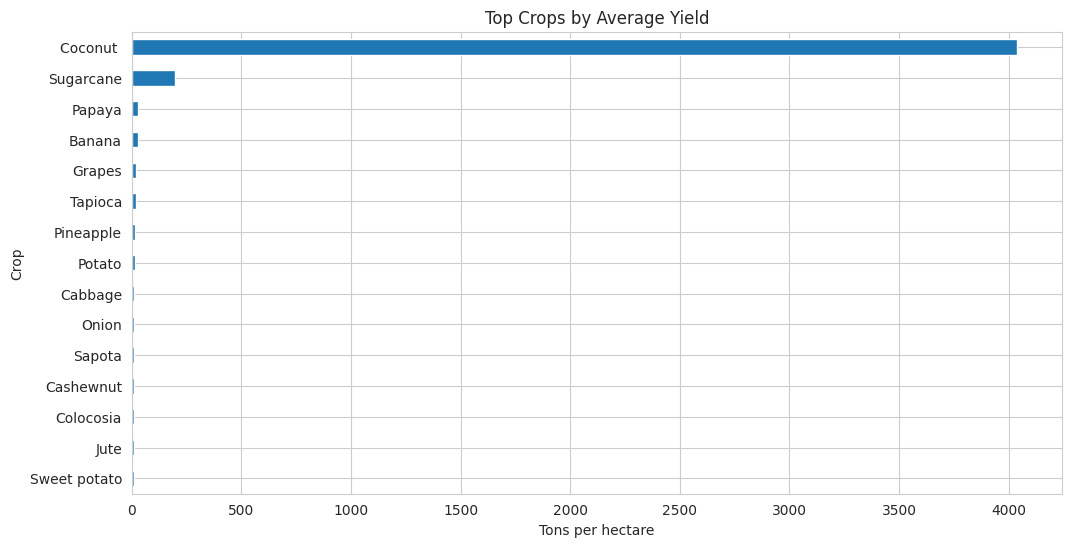

In [106]:
plt.figure(figsize=(12, 6))

production_summary.sort_values(
    "avg_yield",
    ascending=False
).head(15)["avg_yield"].sort_values().plot(
    kind="barh"
)

plt.title("Top Crops by Average Yield")
plt.xlabel("Tons per hectare")

plt.show()

# Analyze yield over time

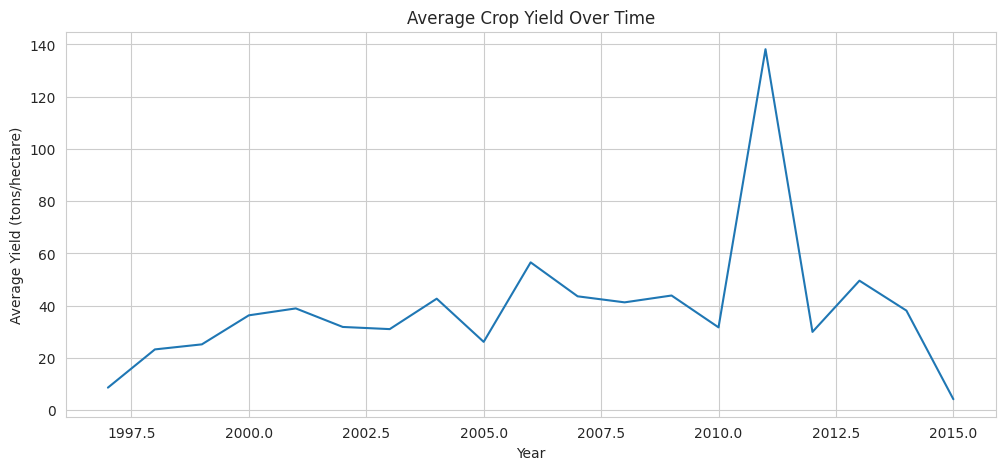

In [117]:
yearly_yield = (
    production_df
    .groupby("Crop_Year")["Yield_ton_per_ha"]
    .mean()
)

plt.figure(figsize=(12, 5))

yearly_yield.plot()

plt.title("Average Crop Yield Over Time")
plt.xlabel("Year")
plt.ylabel("Average Yield (tons/hectare)")

plt.show()

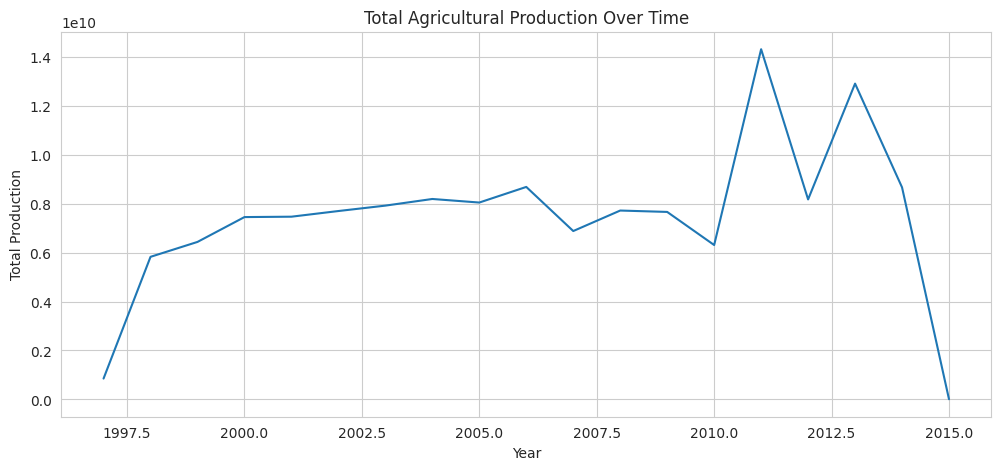

In [118]:
yearly_production = (
    production_df
    .groupby("Crop_Year")["Production"]
    .sum()
)

yearly_production.plot(figsize=(12, 5))

plt.title("Total Agricultural Production Over Time")
plt.xlabel("Year")
plt.ylabel("Total Production")

plt.show()

# Analyze districts

In [120]:
district_summary = (
    production_df
    .groupby("District_Name")
    .agg(
        production=("Production", "sum"),
        area=("Area", "sum"),
        avg_yield=("Yield_ton_per_ha", "mean")
    )
    .sort_values("production", ascending=False)
)

district_summary.head(20)

,production,area,avg_yield
District_Name,,,
KOZHIKODE,1.528074e+10,2988170.95,481.752362
MALAPPURAM,1.451840e+10,3200752.57,477.639879
THIRUVANANTHAPURAM,1.002271e+10,2211754.88,498.287170
THRISSUR,9.923508e+09,2442723.74,439.863686
KANNUR,9.783432e+09,3000089.84,423.676046
EAST GODAVARI,8.271057e+09,11593557.00,227.131809
KASARAGOD,7.732217e+09,1865369.44,461.168581
KOLLAM,7.151945e+09,2160103.98,424.845678
PALAKKAD,6.369382e+09,3677292.76,308.588869


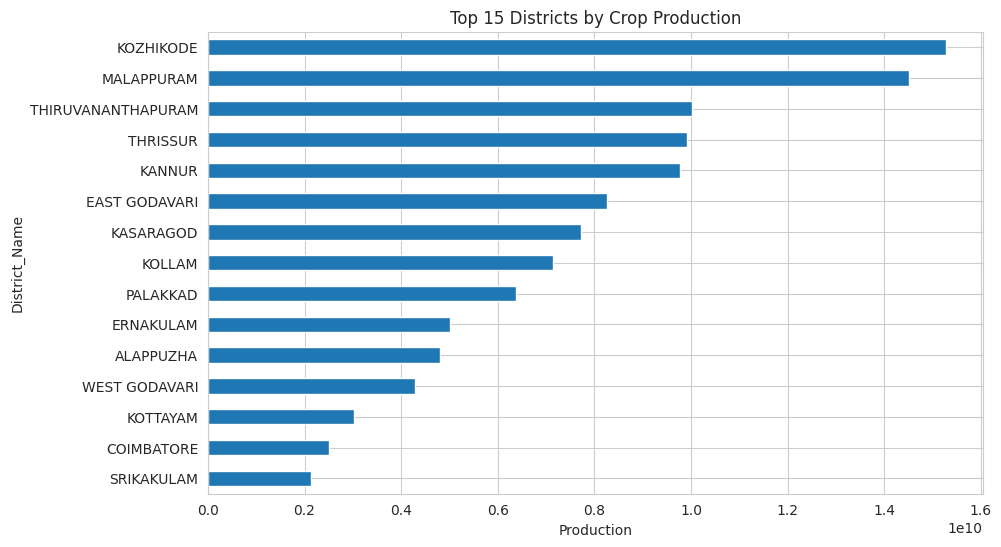

In [121]:
district_summary.head(15)["production"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 15 Districts by Crop Production")
plt.xlabel("Production")

plt.show()

# Now inspect the soil dataset

In [122]:
soil_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


In [123]:
soil_df.describe()

,Crop_Year,Area,Production
count,246091.000000,2.460910e+05,2.423610e+05
mean,2005.643018,1.200282e+04,5.825034e+05
std,4.952164,5.052340e+04,1.706581e+07
min,1997.000000,4.000000e-02,0.000000e+00
25%,2002.000000,8.000000e+01,8.800000e+01
50%,2006.000000,5.820000e+02,7.290000e+02
75%,2010.000000,4.392000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09


In [124]:
soil_df.isnull().sum()

,0
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,3730


In [125]:
soil_df["label"].value_counts()

KeyError: 'label'

In [ ]:
print("Columns:")
print(soil_df.columns.tolist())

print("\nMissing values:")
print(soil_df.isnull().sum())

print("\nDuplicate rows:")
print(soil_df.duplicated().sum())

print("\nCrop distribution:")
print(soil_df["label"].value_counts())

# Analyze NPK by crop

In [ ]:
soil_df.groupby("label")[["N", "P", "K"]].mean()

In [ ]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=soil_df,
    x="label",
    y="N"
)

plt.xticks(rotation=90)
plt.title("Nitrogen Distribution by Crop")
plt.show()

In [ ]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=soil_df,
    x="label",
    y="P"
)

plt.xticks(rotation=90)
plt.title("Phosphorus Distribution by Crop")
plt.show()

In [ ]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=soil_df,
    x="label",
    y="K"
)

plt.xticks(rotation=90)
plt.title("Potassium Distribution by Crop")
plt.show()

# Inspect the weather dataset

In [ ]:
weather_df.info()

In [ ]:
weather_df.head()

In [ ]:
weather_df.describe()

In [ ]:
weather_df.isnull().sum()

# Convert the weather date

In [ ]:
weather_df["Date"] = pd.to_datetime(
    weather_df["Date"],
    errors="coerce"
)

In [ ]:
weather_df["Year"] = weather_df["Date"].dt.year
weather_df["Month"] = weather_df["Date"].dt.month

In [ ]:
weather_df["Date"].min(), weather_df["Date"].max()

# Weather EDA

In [ ]:
# Rainfall:
plt.figure(figsize=(10, 5))

sns.histplot(
    weather_df["Rainfall"],
    bins=50,
    kde=True
)

plt.title("Rainfall Distribution")
plt.show()

In [ ]:
# Temperature:
plt.figure(figsize=(10, 5))

sns.histplot(
    weather_df["Temperature"],
    bins=50,
    kde=True
)

plt.title("Temperature Distribution")
plt.show()

In [ ]:
# Humidity:
plt.figure(figsize=(10, 5))

sns.histplot(
    weather_df["Humidity"],
    bins=50,
    kde=True
)

plt.title("Humidity Distribution")
plt.show()

# Convert daily weather into seasonal features

In [ ]:
weather_yearly = (
    weather_df
    .groupby(["District", "Year"])
    .agg(
        total_rainfall=("Rainfall", "sum"),
        avg_temperature=("Temperature", "mean"),
        avg_humidity=("Humidity", "mean"),
        max_temperature=("Temperature", "max"),
        rainy_days=("Rainfall", lambda x: (x > 2.5).sum())
    )
    .reset_index()
)

# define approximate Indian agricultural seasons:

In [ ]:
def get_season(month):

    if month in [6, 7, 8, 9, 10]:
        return "Kharif"

    elif month in [11, 12, 1, 2, 3]:
        return "Rabi"

    elif month in [4, 5]:
        return "Zaid"

    return "Unknown"

In [ ]:
weather_df["Season"] = weather_df["Date"].dt.month.apply(get_season)

In [ ]:
weather_df["Date"] = pd.to_datetime(
    weather_df["Date"],
    errors="coerce"
)

In [ ]:
weather_df.head()

In [ ]:
weather_df.info()

## Create Year and Month

In [ ]:
weather_df["Year"] = weather_df["Date"].dt.year

weather_df["Month"] = weather_df["Date"].dt.month

In [ ]:
weather_df[
    ["Date", "Year", "Month"]
].head()

## Assign each day to an agricultural season

In [ ]:
def get_season(month):

    if month in [6, 7, 8, 9, 10]:
        return "Kharif"

    elif month in [11, 12, 1, 2, 3]:
        return "Rabi"

    elif month in [4, 5]:
        return "Zaid"

    else:
        return "Unknown"

In [ ]:
weather_df["Season"] = weather_df["Month"].apply(get_season)

In [ ]:
weather_df[
    ["Date", "Month", "Season"]
].head(20)

In [ ]:
def get_agricultural_year(row):

    year = row["Year"]
    month = row["Month"]
    season = row["Season"]

    if season == "Rabi" and month in [1, 2, 3]:
        return year - 1

    return year

In [ ]:
weather_df["Agricultural_Year"] = weather_df.apply(
    get_agricultural_year,
    axis=1
)

# Now aggregate the daily weather

In [ ]:
seasonal_weather = (
    weather_df
    .groupby(
        ["District", "Agricultural_Year", "Season"]
    )
    .agg(
        total_rainfall=("Rainfall", "sum"),
        avg_temperature=("Temperature", "mean"),
        avg_humidity=("Humidity", "mean"),
        max_temperature=("Temperature", "max"),
        min_temperature=("Temperature", "min"),
        rainy_days=("Rainfall", lambda x: (x > 2.5).sum())
    )
    .reset_index()
)

In [ ]:
seasonal_weather.head()

# Add rainfall intensity

In [ ]:
seasonal_weather["rainfall_per_rainy_day"] = (
    seasonal_weather["total_rainfall"] /
    seasonal_weather["rainy_days"].replace(0, np.nan)
)

#  Add temperature variability

In [ ]:
seasonal_weather["temperature_range"] = (
    seasonal_weather["max_temperature"] -
    seasonal_weather["min_temperature"]
)

In [ ]:
temp_std = (
    weather_df
    .groupby(
        ["District", "Agricultural_Year", "Season"]
    )["Temperature"]
    .std()
    .reset_index(name="temperature_std")
)

In [ ]:
seasonal_weather = seasonal_weather.merge(
    temp_std,
    on=["District", "Agricultural_Year", "Season"],
    how="left"
)

# Now merge with your crop-production dataset

In [ ]:
production_df = production_df.rename(
    columns={
        "production_Year": "Agricultural_Year"
    }
)

In [ ]:
final_df = production_df.merge(
    seasonal_weather,
    on=[
        "District",
        "Agricultural_Year",
        "Season"
    ],
    how="left"
)

# Check the merge

In [ ]:
print("Production rows:", len(production_df))
print("Final rows:", len(final_df))

In [ ]:
final_df[
    [
        "total_rainfall",
        "avg_temperature",
        "avg_humidity"
    ]
].isna().mean()

In [ ]:
match_rate = (
    final_df["total_rainfall"].notna().mean()
)

print(f"Weather match rate: {match_rate:.2%}")

#  Does annual rainfall correlate with yield

In [ ]:
kharif = final_df[
    final_df["Season"] == "Kharif"
]

kharif[
    [
        "Yield_ton_per_ha",
        "total_rainfall",
        "avg_temperature",
        "avg_humidity",
        "rainy_days"
    ]
].corr()["Yield_ton_per_ha"].sort_values(
    ascending=False
)


# Visualize it

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=kharif,
    x="total_rainfall",
    y="Yield_ton_per_ha",
    alpha=0.5
)

sns.regplot(
    data=kharif,
    x="total_rainfall",
    y="Yield_ton_per_ha",
    scatter=False,
    color="red"
)

plt.title("Kharif Rainfall vs Crop Yield")
plt.xlabel("Growing Season Rainfall (mm)")
plt.ylabel("Yield (tons/hectare)")

plt.show()

# Even better: do it crop-wise

In [ ]:
rice = final_df[
    (final_df["Crop"].str.lower() == "rice") &
    (final_df["Season"] == "Kharif")
]

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rice,
    x="total_rainfall",
    y="Yield_ton_per_ha"
)

sns.regplot(
    data=rice,
    x="total_rainfall",
    y="Yield_ton_per_ha",
    scatter=False,
    color="red"
)

plt.title("Rice: Growing Season Rainfall vs Yield")

plt.show()

# Merge production + weather

In [ ]:
weather_yearly = weather_yearly.rename(
    columns={"Year": "production_Year"}
)

In [ ]:
ml_df = production_df.merge(
    weather_yearly,
    on=["District", "production_Year"],
    how="left"
)

In [ ]:
ml_df.shape

In [ ]:
ml_df.isnull().sum()

# Check whether the merge actually worked

In [ ]:
weather_match_rate = (
    ml_df["total_rainfall"].notna().mean()
)

print(
    f"Weather match rate: {weather_match_rate:.2%}"
)

# Normalize district names

In [ ]:
def clean_text(x):
    if pd.isna(x):
        return x

    return (
        str(x)
        .strip()
        .lower()
        .replace(" ", "_")
    )

In [ ]:
production_df["District_clean"] = (
    production_df["District"]
    .apply(clean_text)
)

weather_yearly["District_clean"] = (
    weather_yearly["District"]
    .apply(clean_text)
)

In [ ]:
ml_df = production_df.merge(
    weather_yearly,
    on=["District_clean", "production_Year"],
    how="left"
)

# Weather-yield correlation

In [ ]:
corr_cols = [
    "Yield_ton_per_ha",
    "total_rainfall",
    "avg_temperature",
    "avg_humidity"
]

corr_matrix = ml_df[corr_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Weather-Yield Correlation")

plt.show()

# Make scatter plots

In [ ]:
# Rainfall vs yield:

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=ml_df,
    x="total_rainfall",
    y="Yield_ton_per_ha",
    alpha=0.4
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Total Rainfall")
plt.ylabel("Yield (tons/hectare)")

plt.show()

In [ ]:
# Temperature:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=ml_df,
    x="avg_temperature",
    y="Yield_ton_per_ha",
    alpha=0.4
)

plt.title("Temperature vs Crop Yield")

plt.show()

In [ ]:
# Humidity:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=ml_df,
    x="avg_humidity",
    y="Yield_ton_per_ha",
    alpha=0.4
)

plt.title("Humidity vs Crop Yield")

plt.show()

# Do this analysis crop-wise

In [ ]:
selected_crop = "Rice"

rice = ml_df[
    ml_df["Crop"].str.lower() == selected_crop.lower()
]
Then:
sns.scatterplot(
    data=rice,
    x="total_rainfall",
    y="Yield_ton_per_ha"
)

plt.title("Rice: Rainfall vs Yield")

plt.show()

In [ ]:
rice[
    [
        "Yield_ton_per_ha",
        "total_rainfall",
        "avg_temperature",
        "avg_humidity"
    ]
].corr()["Yield_ton_per_ha"]

# Linear Regression baseline

In [ ]:
features = [
    "total_rainfall",
    "avg_temperature",
    "avg_humidity"
]

target = "Yield_ton_per_ha"

In [ ]:
# Drop missing values:
model_df = ml_df[
    features + [target]
].dropna()

In [ ]:
X = model_df[features]
y = model_df[target]

In [ ]:
# Split:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Train:
model = LinearRegression()

model.fit(X_train, y_train)

In [ ]:
# Predict:
y_pred = model.predict(X_test)

In [ ]:
# Evaluate:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

# Save your Week-1 dataset

In [ ]:
ml_df.to_csv(
    "../data/processed/final_ml_dataset.csv",
    index=False
)

In [ ]:
print("Final dataset shape:", ml_df.shape)
display(ml_df.head())